<figure>
  <img src="../images/tudelft_logo.png" alt="image" width="250" align="right"/>
</figure>

# 3b: Wave asymmetry and skewness 

## Introduction

This notebook is one of the three notebooks for this week. It deals with wave shape, which is very important for sediment transport (as we will see in later chapters). When talking about wave shape, we can distinguish between wave skewness and wave asymmetry (Section 5.3 of the [Coastal Dynamics Open Textbook](https://books.open.tudelft.nl/home/catalog/book/202)). We will investigate these topics in this notebook. 

### Theory
Wave asymmetry and skewness can be demonstrated by using a second-order wave with surface elevation $\eta$ that consists of a first harmonic $\eta_1$ and a second harmonic $\eta_2$ 

\begin{equation}
\tag{1}
\eta = a_1 cos(wt-kx-\phi_1) + a_2 cos(2(wt-kx)-\phi_2)
\end{equation}

Compare this equation to Equation 5.21 in the book; as you can see Equation 1 uses $a_1$ and $a_2$ for the amplitudes of the two harmonics (instead of $\hat{\eta}_1$ and $\hat{\eta}_2$). Also, we have added the phases $\phi_1$ and $\phi_2$ of the components to Equation 1. For $\phi_1=\phi_2=0$, you will recognize a second-order Stokes wave. A phase *difference* between the wave components influences the shape of the combined wave. In Chapter 9 (Section 9.7.2), we will see that phase shift of the second harmonic with respect to the first harmonic is $\phi_{2-1}=\phi_2-2\phi_1$. 

Note that for demonstration purposes, we have assumed that the first and second harmonic travel at the same speed, and, thus, that we have a permanent wave form. How can you see from Equation 1 that the second harmonic travels at the same speed as the first harmonic?

### Structure
This notebook consists of two parts: 
1. Investigate the wave shape of skewed and asymmetric waves using a primary and secondary harmonic. This part includes *six numeric questions*. 
2. Investigate the effect of wave skewness and asymmetry on wave-averaged quantities, including sediment transport. This part includes *three multiple-selection questions*


## Import libraries that we use for our analysis

Let's first import the libraries that we use for our analysis by running the next cell.

In [1]:
from pathlib import Path

import panel as pn
import numpy as np
from IPython.display import display

import coastal_dynamics as cd

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
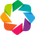

In [2]:
import sys

sys.path.append('../')

from modules import mod_3b, mod_css

pn.extension(raw_css=mod_css.custom_css(font_size="12px"))

In [3]:
questions = cd.read_questions(Path("../hashed_questions/3b_wave_asymmetry_and_skewness_hashed.json"))

question_industry = cd.QuestionIndustry(questions)

cd.UseAnswersApp("Q3b").serve()

Column
    [0] Markdown(str)
    [1] Button(name='Help')
    [2] StaticText(value=' ')
    [3] Row
        [0] Button(name='Disregard saved answers')
        [1] Button(button_type='danger', name='Are you sure?', visible=False)
    [4] StaticText(value=' ')
    [5] ParamFunction(function, _pane=Str, defer_load=False)

## Part 1: Asymmetry and skewness for second-order wave

By running the next cell you will get an interactive graph displaying the surface elevation according to Equation 1. The phase on the horizontal axis is the phase $S=\omega t - k x$ of the *primary* harmonic. The graph requires input for the amplitudes and phases of each component. Herewith, you can investigate the impact of the amplitudes and the phases on the wave shape (asymmetry and skewness). 

In [4]:
mod_3b.second_order_waves()

Output()

### Figures 5.13 and 5.16

We will now use the interactive graph to reproduce Figures 5.13 and 5.16 of the book. 

#### Figure 5.13
First have a look at Figure 5.13 of the book. Which amplitudes and phases of wave component $\eta_1$ and $\eta_2$ will reproduce Figure 5.13? Use both Equation 1 and the interactive graph to find the answers. Note that in the book the y-axis is scaled with (i.e., divided by) the amplitude of the first harmonic component. In the interactive plot, you should stick to $a_1 = 1$ to have the same values on the y-axis. 

#### Figure 5.16

Now do the same for Figure 5.16. 

#### Questions
When you have determined the ampitudes and phases for both figures using the interactive graph, you can verify your findings in a few numeric questions (for this, run the cell below). 

In [5]:
q = [
    "Q3b-second_order_wave_5.13-eta1",
    "Q3b-second_order_wave_5.13-eta2",
    "Q3b-second_order_wave_5.13-phi2",
    "Q3b-second_order_wave_5.16-eta1",
    "Q3b-second_order_wave_5.16-eta2",
    "Q3b-second_order_wave_5.16-phi2"
]

question_industry.serve(q)

Column(width_policy='max')
    [0] Column(width_policy='max')
        [0] StaticText(name='Q-1', sizing_mode='stretch_width', value='What are the values of a₁...)
        [1] FloatInput(name='Your Answer', width=200)
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [1] Column(width_policy='max')
        [0] StaticText(name='Q-2', sizing_mode='stretch_width', value='What are the values of a₁...)
        [1] FloatInput(name='Your Answer', width=200)
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [2] Column(width_policy='max')
        [0] StaticText(name='Q-3', sizing_mode='stretch_width', value='What are the values of a₁...)
        [1] FloatInput(name='Your Answer', width=200)
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [3] Column(width_policy='max')
        [0] StaticText(name='Q-4', sizing_mode='stretch_width', value='What are the values of a₁...)
        [1] FloatInput(name='Your Answer', width=200)
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [4] Column(width_policy='max')
        [0] StaticText(name='Q-5', sizing_mode='stretch_width', value='What are the values of a₁...)
        [1] FloatInput(name='Your Answer', width=200)
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [5] Column(width_policy='max')
        [0] StaticText(name='Q-6', sizing_mode='stretch_width', value='What are the values of a₁...)
        [1] FloatInput(name='Your Answer', width=200)
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)

### Figure 5.15

We are now going to reproduce the total surface elevation as shown in Figure 5.15 (the solid lines). First, we will do the left panel, which has x/L on the horizontal axis, and then the right panel, which has t/T on the horizontal axis. Again we will not scale with $a_1$, but use $a_1 = 1$. 

#### Left panel of Figure 5.15
Can you reproduce the solid line in the left panel of Figure 5.15? Assume t = 0 s and rewrite Equation 1, such that the surface elevation is a function of x/L. Now fill in this equation in the code cell below and run the cell to plot your answer and the correct answer. Note that in the code cell, the input values are already given. How do these compare to the values you found above and why? 

In [6]:
input_values = {
    "x_L": np.linspace(-0.1, 1.1, 100),   
    "eta1": 1,
    "eta2": 0.2,
    "phi1": 0,
    "phi2": -0.5,
}

xL, eta1, eta2, phi1, phi2 = input_values.values()

# Replace None by your formula for eta
def formula_student_x_L(xL, eta1, eta2, phi1, phi2):
    eta = None             # This function is called function 1 in the check of the plot

    return eta

output, figure = mod_3b.check_second_order_waves_x_L(input_values, [formula_student_x_L])

print(output)
display(figure)

Your function is: 
Function 1 is incorrect.



:Layout
   .Curve.Student_function :Curve   [x]   (y)
   .Curve.Correct_function :Curve   [x]   (y)

#### Right panel of Figure 5.15

Can you now code the equation to reproduce the solid line in the right panel of Figure 5.15? This requires that you rewrite Equation 1, such that the surface elevation becomes a function of t/T and assume that we are at the location of point A in the left plot. You can type your equation in the code cell below to check your outcome.

Now consider the following question: What are the most striking differences between the left and the right panel of Figure 5.15?

In [7]:
input_values = {
    "t_T": np.linspace(-0.1, 1.1, 100),
    "eta1": 1,
    "eta2": 0.2,
    "phi1": 0,
    "phi2": -0.5,
}

tT, eta1, eta2, phi1, phi2 = input_values.values()

# Replace None by your formula for eta
def formula_student_t_T(tT, eta1, eta2, phi1, phi2):
    eta = None             # This function is called function 1 in the check of the plot


    return eta

output, figure = mod_3b.check_second_order_waves_t_T(input_values, [formula_student_t_T])
print(output)
display(figure)

Your function is: 
Function 1 is incorrect.



:Layout
   .Curve.Student_function :Curve   [x]   (y)
   .Curve.Correct_function :Curve   [x]   (y)

## Part 2: Effect skewness & asymmetry on sediment transport

### Figures 5.14 and 5.17

Later in this course, we will consider how the wave shape influences sediment transport. A common assumption is that sediment transport is proportional to higher powers of the orbital velocity signal. As a first step, let us consider what higher powers of the surface elevation look like. Remember that under a progressive wave (like we see in the nearshore), velocity and surface elevation are in phase. Here we compare $\eta$ with $\eta^3$, while varying the phase of the second harmonic component, as in Figure 5.14 and 5.17. 

#### What to do with the interactive graph?
1. Run the code cell below to obtain an interactive graph (and some questions).
2. We have already filled in the first harmonic component, so you can leave these values untouched. You can see the results of the first harmonic component alone in the left panel. Verify that this figure is identical to the panel for sinusoidal waves in Figure 5.14.
3. Now choose the amplitude and phase of the second harmonic for skewed waves.
4. Compare the middle panel with the panel for skewed waves in either Figure 5.14 or 5.17. If you have chosen the amplitude and phase of the second harmonic correctly, the figures are identical.
5. Now choose the amplitude and phase of the second harmonic for asymmetric waves.
6. Compare the right panel with the panel for asymmetric waves in either Figure 5.14 or 5.17. If you have chosen the amplitude and phase of the second harmonic correctly, the figures are identical.

#### Reflection
Study the figures to see how the peaks and shape of $\eta$ and $\eta^3$ vary between the panels. What is the influence on the *phase-averaged value* of $\eta^3$ when the amplitudes and phases of the wave components change? And as a final thought provoking question on this section: what may be the implications for the corresponding time-varying transport signal and the wave-averaged (or net or time-averaged) transport at a certain location? Verify your ideas using the questions below the graph.

In [8]:
mod_3b.asymmetric()

Output()

In [9]:
q = [
    "Q3b-third_moment_left",
    "Q3b-third_moment_middle",
    "Q3b-third_moment_right"
]

question_industry.serve(q)

Column(width_policy='max')
    [0] Column(width_policy='max')
        [0] StaticText(name='Q-7', sizing_mode='stretch_width', value='Assume a fixed location. ...)
        [1] CheckBoxGroup(name='Options', options=['The time-averaged value ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [1] Column(width_policy='max')
        [0] StaticText(name='Q-8', sizing_mode='stretch_width', value='Assume a fixed location. ...)
        [1] CheckBoxGroup(name='Options', options=['The time-averaged value ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [2] Column(width_policy='max')
        [0] StaticText(name='Q-9', sizing_mode='stretch_width', value='Assume a fixed location. ...)
        [1] CheckBoxGroup(name='Options', options=['The time-averaged value ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)

### The end

You have reached the end of this Notebook 3b. You can continue with this week's last notebook, which is Notebook 3c on radiation stresses and wave forces.